# 08_Multiple Linear Regression

# Multiple Linear Regression

Simple Linear Regression에서는 하나의 Input Variable을 이용하여 Numerical Output을 예측하였다.

California Housing Data에서는 `MedInc`를 이용하여 `MedHouseVal`을 예측하였다.

그러나 House Value는 Income 하나만으로 결정되지 않는다.

House Age, Room 수, Population 등 여러 Variables가 House Value와 관련될 수 있다.

그렇다면 다음과 같은 질문을 할 수 있다.

> 여러 Input Variables를 함께 사용하면 더 잘 예측할 수 있을까?

이번 강의에서는 여러 Features를 동시에 사용하는 Multiple Linear Regression을 학습한다.

> One Feature → Multiple Features

In [1]:
from google.colab import drive

# Google Drive를 Colab에 Mount
drive.mount('/content/drive')

# 강의용 Data가 저장된 Folder

data_path = "/content/drive/My Drive/Colab Notebooks/0_ML/Input/"

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Data 읽기
df = pd.read_csv(data_path+"another4_data.csv")

# Data 확인
display(df.head())

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

,x1,x2,x3,y
0,-1.254599,1.420316,-3.968761,-13.539990
1,4.507143,-4.158600,4.025529,46.355000
2,2.319939,-3.383713,0.052524,23.723278
3,0.986585,3.985542,3.264575,15.976485
4,-3.439814,1.064291,-1.799504,-10.753337


Shape: (200, 4)
Columns: ['x1', 'x2', 'x3', 'y']


## Multiple Features

현재 Data에는 세 개의 Input Features와 하나의 Output이 있다.

Input Features:

$x_1$, $x_2$, $x_3$

Output:

$y$

우리는 다음 Problem을 해결하려고 한다.

> $x_1$, $x_2$, $x_3$를 이용하여 $y$를 예측할 수 있을까?

어떤 Regression Method를 사용할지 결정하기 전에 먼저 Data를 관찰해 보자.

## Relationship between Each Feature and Output

먼저 각각의 Feature와 Output $y$ 사이의 관계를 살펴보자.

다음 세 관계를 각각 확인한다.

$x_1$과 $y$

$x_2$와 $y$

$x_3$와 $y$

Scatter Plot을 이용하여 각 Feature와 Output 사이에 어떤 Pattern이 존재하는지 관찰한다.

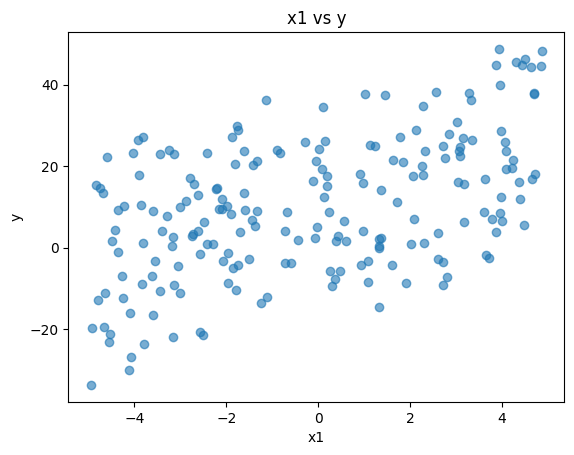

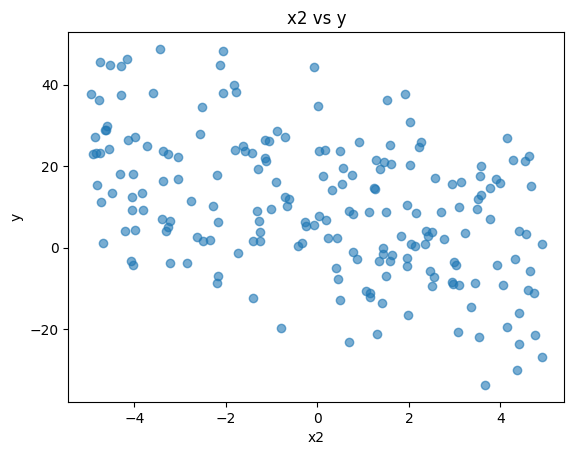

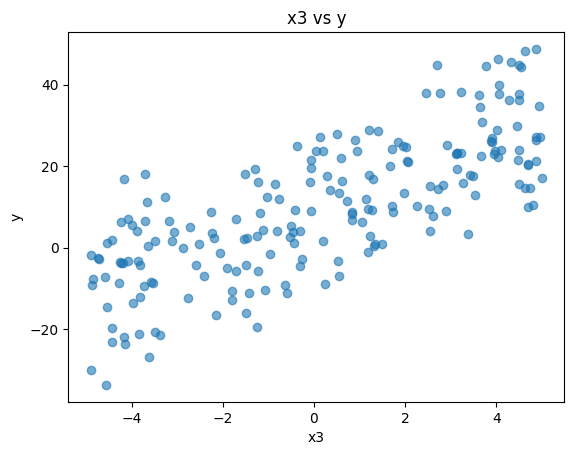

In [3]:
# x1과 y의 관계
plt.scatter(df["x1"], df["y"], alpha=0.6)

plt.xlabel("x1")
plt.ylabel("y")
plt.title("x1 vs y")

plt.show()


# x2와 y의 관계
plt.scatter(df["x2"], df["y"], alpha=0.6)

plt.xlabel("x2")
plt.ylabel("y")
plt.title("x2 vs y")

plt.show()


# x3와 y의 관계
plt.scatter(df["x3"], df["y"], alpha=0.6)

plt.xlabel("x3")
plt.ylabel("y")
plt.title("x3 vs y")

plt.show()

## What Can We Observe?

세 Scatter Plot을 관찰하면 각 Feature와 $y$ 사이에 대체로 Linear Relationship이 존재하는 것을 볼 수 있다.

그러나 $y$는 하나의 Feature만으로 결정되는 것처럼 보이지 않는다.

$x_1$과 $y$ 사이에도 관계가 있고,

$x_2$와 $y$ 사이에도 관계가 있으며,

$x_3$와 $y$ 사이에도 관계가 있다.

그렇다면 세 Features를 각각 따로 사용하는 것보다 동시에 사용하는 방법을 생각할 수 있다.

> Can we predict $y$ using $x_1$, $x_2$, and $x_3$ together?

## From Simple to Multiple Linear Regression

Simple Linear Regression은 하나의 Input을 사용한다.

$$
\hat{y}=w_1x_1+b
$$

Multiple Linear Regression은 여러 Input을 동시에 사용한다.

$$
\hat{y}
=
w_1x_1
+w_2x_2
+\cdots
+w_px_p
+b
$$

각 $x_j$는 하나의 Feature이고 $w_j$는 해당 Feature에 대응하는 Weight이다.

따라서 Feature가 여러 개라면 Model도 여러 개의 Weight를 학습한다.

In [4]:
# 각 Feature와 y의 Correlation 확인
print("x1 - y:", df["x1"].corr(df["y"]))
print("x2 - y:", df["x2"].corr(df["y"]))
print("x3 - y:", df["x3"].corr(df["y"]))

x1 - y: 0.4982749068286541
x2 - y: -0.46171377322073265
x3 - y: 0.758806654805539


## Choosing the Model

Visualization과 Correlation을 통해 세 Features 모두 $y$와 관계가 있음을 확인하였다.

따라서 하나의 Feature만 선택하기보다 세 Features를 함께 이용하여 $y$를 예측해 보자.

Input:

$$
X=(x_1,x_2,x_3)
$$

Output:

$$
y
$$

Method:

Multiple Linear Regression

이제 Data를 이용하여 Model의 Weight와 Bias를 학습한다.

## Use All Features

이제 `x1`, `x2`, `x3`를 모두 Input Features로 사용한다.

$$
X=(x_1,x_2,x_3)
$$

Multiple Linear Regression Model은 다음과 같다.

$$
\hat{y}
=
w_1x_1+w_2x_2+w_3x_3+b
$$

Training을 통해 세 개의 Weight와 하나의 Bias를 결정한다.

In [5]:
from sklearn.linear_model import LinearRegression

# Input Features와 Output 선택
X = df[["x1", "x2", "x3"]]
y = df["y"]

# Multiple Linear Regression Model 생성
model = LinearRegression()

# Model Training
model.fit(X, y)

print("Training Complete")

Training Complete


## Learned Parameters

Training이 완료되면 Model은 세 개의 Weight와 하나의 Bias를 가지게 된다.

$$
\hat{y}
=
w_1x_1+w_2x_2+w_3x_3+b
$$

각 Weight의 Sign을 통해 해당 Feature가 Prediction에 어떤 방향으로 작용하는지 확인할 수 있다.

- Positive Weight: Feature가 증가하면 Prediction이 증가하는 방향
- Negative Weight: Feature가 증가하면 Prediction이 감소하는 방향

학습된 Parameter를 확인해 보자.

In [6]:
# 학습된 Weight 확인
weights = pd.DataFrame({
    "Feature": ["x1", "x2", "x3"],
    "Weight": model.coef_
})

display(weights)

# 학습된 Bias 확인
print("Bias:", model.intercept_)

,Feature,Weight
0,x1,2.991036
1,x2,-2.050447
2,x3,4.055925


Bias: 9.87021953756256


## Learned Regression Equation

Training 결과로 얻은 Weight와 Bias를 이용하면 Model이 학습한 Regression Equation을 확인할 수 있다.

중요한 것은 이 식을 우리가 미리 정한 것이 아니라는 점이다.

Model은 주어진 Data를 이용하여 각 Feature와 Output 사이의 관계를 학습하였다.

> Data → Training → Parameters → Regression Equation

In [7]:
# 학습된 Parameter
w1, w2, w3 = model.coef_
b = model.intercept_

# 학습된 Regression Equation 출력
print(
    f"y = {w1:.3f} x1 "
    f"+ {w2:.3f} x2 "
    f"+ {w3:.3f} x3 "
    f"+ {b:.3f}"
)

y = 2.991 x1 + -2.050 x2 + 4.056 x3 + 9.870


## Prediction

Training된 Model을 이용하면 새로운 `x1`, `x2`, `x3`가 주어졌을 때 $y$를 예측할 수 있다.

Model을 Training할 때 세 Features를 사용했으므로 새로운 Data에도 동일한 세 Features가 필요하다.

$$
(x_1,x_2,x_3)
\rightarrow
\hat{y}
$$

In [8]:
# 새로운 Input Data
new_data = pd.DataFrame({
    "x1": [1.0],
    "x2": [2.0],
    "x3": [-1.0]
})

# Prediction
prediction = model.predict(new_data)

display(new_data)
print("Predicted y:", prediction[0])

,x1,x2,x3
0,1.0,2.0,-1.0


Predicted y: 4.7044354862129705


## Evaluation

Model을 Training한 다음에는 Prediction 결과를 평가해야 한다.

07강과 동일하게 MSE와 $R^2$를 사용한다.

MSE는 Actual Value와 Predicted Value 사이의 Error를 나타낸다.

$R^2$는 Model이 Output의 변화를 얼마나 설명하고 있는지를 나타낸다.

Model을 만드는 것만으로 Machine Learning 과정이 끝나는 것이 아니다.

> Training → Prediction → Evaluation

In [9]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# 전체 Data에 대한 Prediction
y_pred = model.predict(X)

# Model Evaluation
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("MSE:", mse)
print("R-squared:", r2)

MSE: 4.069516574138538
R-squared: 0.9856275837684556


## How Are the Weights Determined?

Multiple Linear Regression Model은 다음과 같다.

$$
\hat{y}
=
w_1x_1+w_2x_2+w_3x_3+b
$$

Training의 목적은 Actual Value $y$와 Prediction $\hat{y}$ 사이의 Error가 가장 작아지도록

$$
w_1,\;w_2,\;w_3,\;b
$$

를 결정하는 것이다.

각 Data에서 발생하는 Error를 Residual이라고 한다.

$$
e_i
=
y_i-\hat{y}_i
$$

Linear Regression에서는 Residual의 제곱합을 최소화한다.

$$
\min_{w_1,w_2,w_3,b}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
$$

이 방법을 Least Squares라고 한다.

## Least Squares in Matrix Form

Bias까지 하나의 Parameter로 포함하면 Multiple Linear Regression을 Matrix 형태로 표현할 수 있다.

$$
X=
\begin{bmatrix}
1 & x_{11} & x_{12} & x_{13}\\
1 & x_{21} & x_{22} & x_{23}\\
\vdots & \vdots & \vdots & \vdots\\
1 & x_{n1} & x_{n2} & x_{n3}
\end{bmatrix}
$$

$$
w=
\begin{bmatrix}
b\\
w_1\\
w_2\\
w_3
\end{bmatrix},
\qquad
y=
\begin{bmatrix}
y_1\\
y_2\\
\vdots\\
y_n
\end{bmatrix}
$$

그러면 Prediction은

$$
\hat{y}=Xw
$$

이고, Least Squares Problem은 다음과 같이 표현된다.

$$
\min_w \|Xw-y\|_2^2
$$

## Solution of Least Squares

Least Squares Problem은 수학적으로 직접 풀 수 있다.

$$
\min_w \|Xw-y\|_2^2
$$

$X^TX$가 Invertible한 경우 Solution은

$$
w=(X^TX)^{-1}X^Ty
$$

로 주어진다.

따라서 Linear Regression의 Training은 Data로부터 Weight와 Bias를 결정하는 수학적인 Optimization 과정이다.

`LinearRegression.fit()`은 이러한 Least Squares Problem을 수치적으로 해결한다.

In [11]:
# Matrix X 구성
import numpy as np

X_matrix = np.column_stack([
    np.ones(len(df)),
    df["x1"],
    df["x2"],
    df["x3"]
])

y_matrix = df["y"].values

# Least Squares Solution
w = np.linalg.inv(X_matrix.T @ X_matrix) @ X_matrix.T @ y_matrix

print("Least Squares")
print("Bias:", w[0])
print("Weights:", w[1:])

print()

print("LinearRegression")
print("Bias:", model.intercept_)
print("Weights:", model.coef_)

Least Squares
Bias: 9.87021953756256
Weights: [ 2.9910359  -2.05044746  4.05592504]

LinearRegression
Bias: 9.87021953756256
Weights: [ 2.9910359  -2.05044746  4.05592504]


### HW_08

`Input/another5_data.csv`를 이용하여 Multiple Linear Regression을 수행하고 다음 질문에 답하시오.

- Input Features의 이름을 모두 적으시오.
- 학습된 각 Weight를 소수점 셋째 자리까지 적으시오.
- 학습된 Bias를 소수점 셋째 자리까지 적으시오.
- Model의 MSE를 소수점 셋째 자리까지 적으시오.
- Model의 $R^2$를 소수점 셋째 자리까지 적으시오.

답만 제출하시오.